* [인프런 - 단 두 장의 문서로 데이터 분석과 시각화 뽀개기](https://www.inflearn.com/course/%ED%8C%90%EB%8B%A4%EC%8A%A4-Pandas)

### 서울시에서 공개한 코로나19 발생동향 분석

In [258]:
# pandas, numpy 라이브러리 로드하기

import pandas as pd
import numpy as np

In [259]:
# file_name 변수에 read_html 로 저장한 파일명을 지정해 줍니다.
file_name = f"seoul_covid_6_30_.csv"
file_name

'seoul_covid_6_30_.csv'

In [260]:
# 아래 코드의 주석을 풀고 바로 읽어올 수도 있습니다.
pd.read_csv(file_name) 

# read_csv 로 csv 파일을 불러와 주세요.
df = pd.read_csv(file_name, encoding="utf-8")
df.shape

(1321, 7)

In [261]:
df

,연번,환자,확진일,거주지,여행력,접촉력,조치사항
0,1321,12830,6.30.,영등포구,-,영등포구 확진자 접촉,-
1,1320,12829,6.30.,관악구,-,확인 중,보라매병원
2,1319,12831,6.30.,영등포구,-,확인 중,중앙대학교병원
3,1318,12808,6.30.,관악구,-,강남구 역삼동 모임,보라매병원
4,1317,12809,6.30.,관악구,-,강남구 역삼동 모임,보라매병원
...,...,...,...,...,...,...,...
1316,5,9,1.31.,성북구,-,#5 접촉,서울의료원(퇴원)
1317,4,7,1.30.,마포구,중국 우한시,해외 접촉,서울의료원(퇴원)
1318,3,6,1.30.,종로구,-,#3 접촉,서울대학교병원(퇴원)
1319,2,5,1.30.,중랑구,중국 우한시,해외 접촉,서울의료원(퇴원)


In [262]:
# "연번"을 기준으로 역순으로 정렬합니다.

df = df.sort_values(by="연번", ascending=False)

In [263]:
# head 로 미리보기를 합니다.

df.head()

,연번,환자,확진일,거주지,여행력,접촉력,조치사항
0,1321,12830,6.30.,영등포구,-,영등포구 확진자 접촉,-
1,1320,12829,6.30.,관악구,-,확인 중,보라매병원
2,1319,12831,6.30.,영등포구,-,확인 중,중앙대학교병원
3,1318,12808,6.30.,관악구,-,강남구 역삼동 모임,보라매병원
4,1317,12809,6.30.,관악구,-,강남구 역삼동 모임,보라매병원


In [264]:
# tail 로 미리보기를 합니다.

df.tail()

,연번,환자,확진일,거주지,여행력,접촉력,조치사항
1316,5,9,1.31.,성북구,-,#5 접촉,서울의료원(퇴원)
1317,4,7,1.30.,마포구,중국 우한시,해외 접촉,서울의료원(퇴원)
1318,3,6,1.30.,종로구,-,#3 접촉,서울대학교병원(퇴원)
1319,2,5,1.30.,중랑구,중국 우한시,해외 접촉,서울의료원(퇴원)
1320,1,2,1.24.,강서구,중국 우한시,해외 접촉,국립중앙의료원(퇴원)


### 시각화 도구 불러오기

<Axes: title={'center': '한글 제목'}>

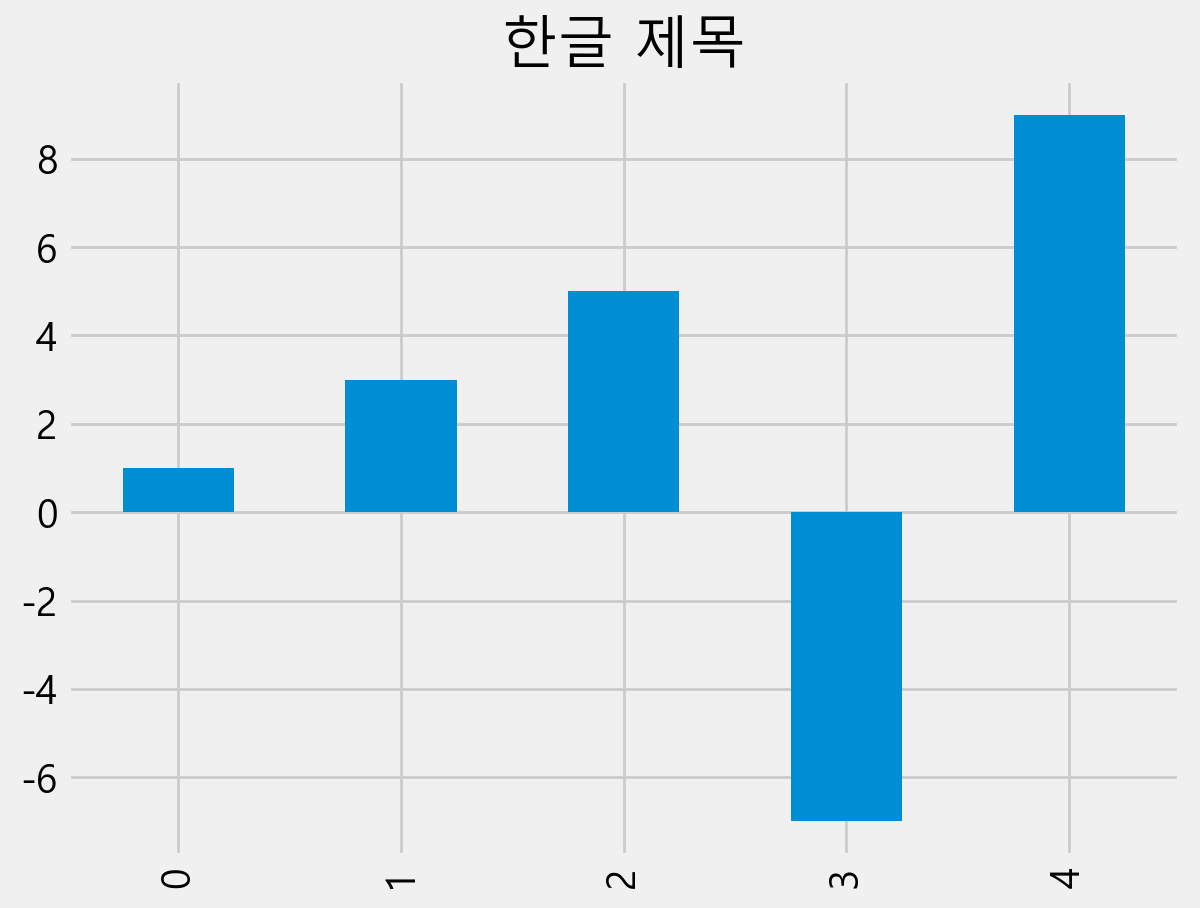

In [265]:
# matplotlib.pyplot 을 통해 한글폰트를 설정합니다.
# plt.style.use 로 "fivethirtyeight" 스타일을 사용해 봅니다.

import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)
plt.style.use("fivethirtyeight")

pd.Series([1, 3, 5, -7, 9]).plot.bar(title="한글 제목")

### 시각화 선명하게 설정하기

In [266]:
# retina 디스플레이가 지원되는 환경에서 시각화의 폰트가 좀 더 선명해 보입니다.

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### 확진일

In [267]:
# 확진일의 빈도수를 봅니다. 어느 날짜에 가장 많이 확진이 되었는지 봅니다.

df

,연번,환자,확진일,거주지,여행력,접촉력,조치사항
0,1321,12830,6.30.,영등포구,-,영등포구 확진자 접촉,-
1,1320,12829,6.30.,관악구,-,확인 중,보라매병원
2,1319,12831,6.30.,영등포구,-,확인 중,중앙대학교병원
3,1318,12808,6.30.,관악구,-,강남구 역삼동 모임,보라매병원
4,1317,12809,6.30.,관악구,-,강남구 역삼동 모임,보라매병원
...,...,...,...,...,...,...,...
1316,5,9,1.31.,성북구,-,#5 접촉,서울의료원(퇴원)
1317,4,7,1.30.,마포구,중국 우한시,해외 접촉,서울의료원(퇴원)
1318,3,6,1.30.,종로구,-,#3 접촉,서울대학교병원(퇴원)
1319,2,5,1.30.,중랑구,중국 우한시,해외 접촉,서울의료원(퇴원)


In [268]:
# "확진일" 컬럼의 데이터가 날짜 형태가 아니라 문자형태 입니다.

df["확진일"].value_counts()

확진일
3.10.    46
6.12.    30
6.06.    29
6.05.    27
3.9.     26
         ..
3.3.      1
2.7.      1
2.6.      1
2.2.      1
1.24.     1
Name: count, Length: 131, dtype: int64

In [269]:
# 데이터 타입을 변경해서 날짜형태로 변환합니다.
# 판다스의 to_datetime 을 사용해서 날짜 타입으로 변경할 수 있습니다.
# 연도가 없기 때문에 2020년을 날짜에 추가하고 "-" 문자로 날짜를 연결해 줍니다.

df["확진일자"] = pd.to_datetime("2020-" + df["확진일"].str.replace(".", "-"))
df[["확진일", "확진일자"]].head()

,확진일,확진일자
0,6.30.,2020-06-30
1,6.30.,2020-06-30
2,6.30.,2020-06-30
3,6.30.,2020-06-30
4,6.30.,2020-06-30


In [270]:
# 월만 추출합니다.

df["월"] = df["확진일자"].dt.month
df[["확진일", "확진일자", "월"]].tail()

,확진일,확진일자,월
1316,1.31.,2020-01-31,1
1317,1.30.,2020-01-30,1
1318,1.30.,2020-01-30,1
1319,1.30.,2020-01-30,1
1320,1.24.,2020-01-24,1


In [271]:
# 해당 연도의 몇번째 "주"인지 추출합니다.
# df["확진일자"].dt.week -> 예전 방식(현재 사용 X)

df["주"] = df["확진일자"].dt.isocalendar().week
df[["확진일", "확진일자", "월", "주"]].head()

,확진일,확진일자,월,주
0,6.30.,2020-06-30,6,27
1,6.30.,2020-06-30,6,27
2,6.30.,2020-06-30,6,27
3,6.30.,2020-06-30,6,27
4,6.30.,2020-06-30,6,27


### 선그래프 그리기
[Visualization — pandas documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html)

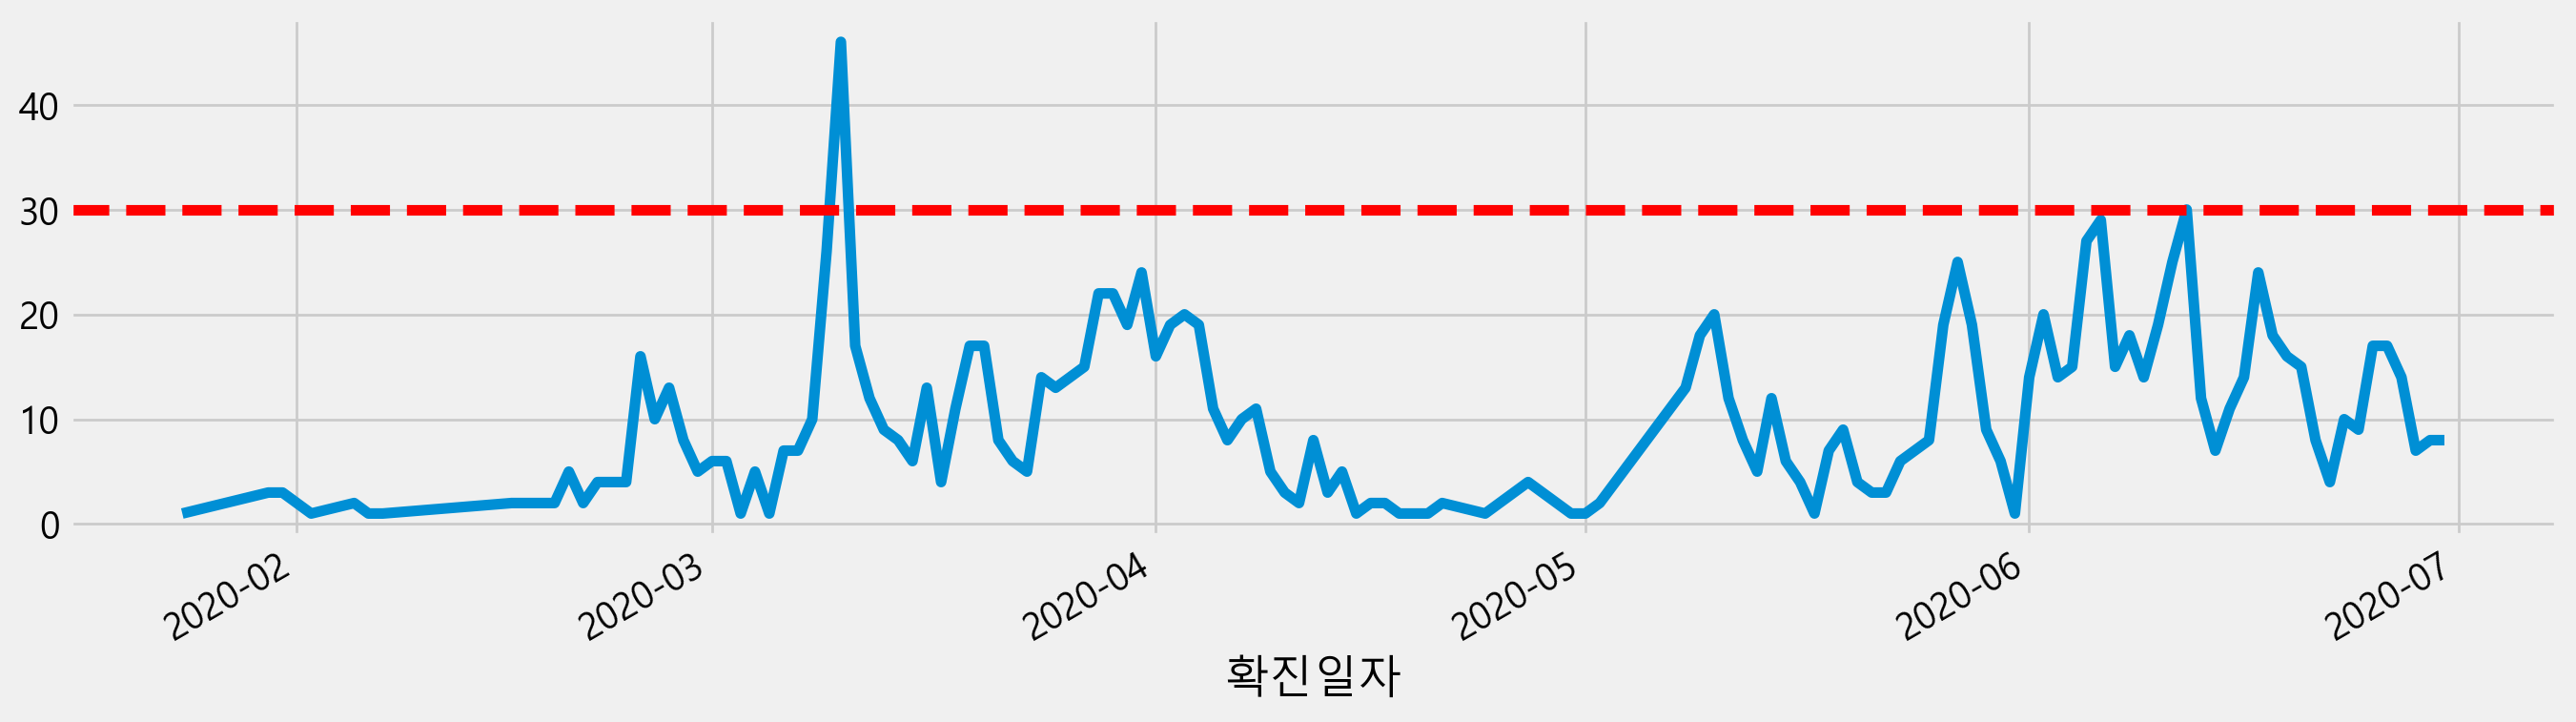

In [272]:
# 확진일자로 선그래프를 그립니다.
# 시간순으로 그래프를 그림
# 날짜순으로 선그래프 그리기 -> sort_index() 사용

df["확진일자"].value_counts().sort_index().plot(figsize=(15,4))
plt.axhline(30, color="red", linestyle="--") # y=30 위치에 빨간 가로 점선 그리기

### 선그래프에 값 표시하기

In [ ]:
# 일자별 확진자수를 선그래프로 그립니다.
# 연도는 모두 2020년이기 때문에 월일만 표기되도록 슬라이싱을 사용해 "월일" 컬럼을 만듭니다.

df["월일"] = df["확진일자"].astype(str).map(lambda x : x[-5:])
day_count = df["월일"].value_counts().sort_index()

# loc는 정확하게 인덱스 값이 매치 가능해야함
day_count.iloc[2]

np.int64(3)

In [387]:
for i in range(len(day_count)):
    print(i, day_count.iloc[i])

0 1
1 3
2 3
3 1
4 2
5 1
6 1
7 2
8 2
9 5
10 2
11 4
12 4
13 4
14 16
15 10
16 13
17 8
18 5
19 6
20 6
21 1
22 5
23 1
24 7
25 7
26 10
27 26
28 46
29 17
30 12
31 9
32 8
33 6
34 13
35 4
36 11
37 17
38 17
39 8
40 6
41 5
42 14
43 13
44 14
45 15
46 22
47 22
48 19
49 24
50 16
51 19
52 20
53 19
54 11
55 8
56 10
57 11
58 5
59 3
60 2
61 8
62 3
63 5
64 1
65 2
66 2
67 1
68 1
69 1
70 2
71 1
72 4
73 1
74 1
75 2
76 13
77 18
78 20
79 12
80 8
81 5
82 12
83 6
84 4
85 1
86 7
87 9
88 4
89 3
90 3
91 6
92 7
93 8
94 19
95 25
96 19
97 9
98 6
99 1
100 14
101 20
102 14
103 15
104 27
105 29
106 15
107 18
108 14
109 19
110 25
111 30
112 12
113 7
114 11
115 14
116 24
117 18
118 16
119 15
120 8
121 4
122 10
123 9
124 17
125 17
126 14
127 7
128 8
129 8


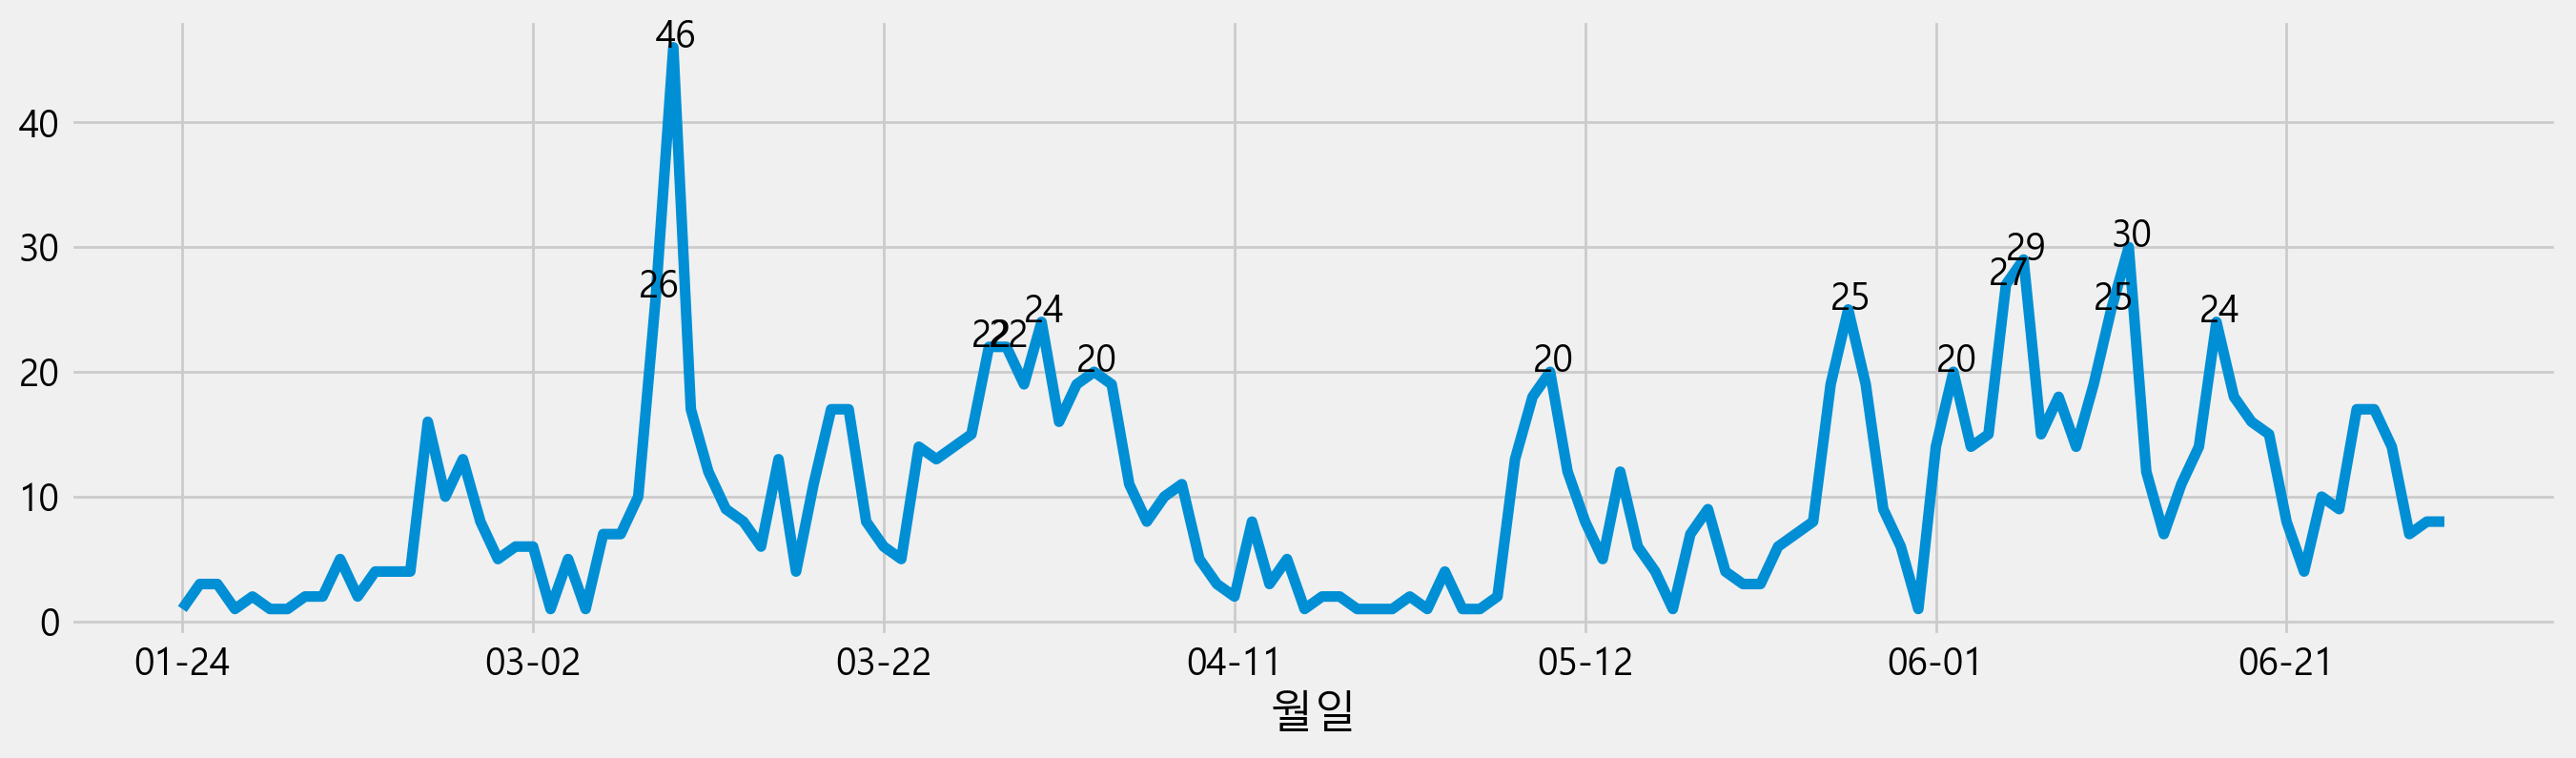

In [392]:
g = day_count.plot(figsize=(15, 4))
for i in range(len(day_count)):
    case_count = day_count.iloc[i]
    if case_count >= 20:
        g.text(x=i-1, y=case_count, s=case_count)

### 확진자가 가장 많이 나온 날

In [274]:
# describe 를 통해 일자별 확진자수를 describe를 통해 요약해 봅니다.



In [275]:
# 확진자가 가장 많았던 날을 찾습니다.



In [276]:
# 확진자가 가장 많았던 날의 발생이력을 찾습니다.



### 막대그래프 그리기

In [277]:
# 선그래프로 그렸던 그래프를 막대그래프로 그립니다.



### 최근 데이터만 슬라이싱으로 나눠 그리기

In [278]:
# 슬라이싱을 통해 최근 데이터만 그립니다.



### 월별 확진자 수 그리기

In [279]:
# 월별 확진자수에 대한 빈도수를 구해서 시각화 합니다.



### 주단위 확진자수 그리기

In [280]:
# 주별로 빈도수를 구합니다.




In [281]:
# 주단위 빈도수 막대그래프로 그리기


### 월-주 함께 그리기

In [282]:
# groupby 를 통해 "월", "주" 로 그룹화 하여 빈도수를 계산합니다.



In [283]:
# 월-주 를 함께 그래프에 표현하기




## 모든 날짜를 행에 만들어 주기
* 확진자가 없는 날의 데이터도 만들어 줍니다.

In [284]:
# 첫 확진일 부터 마지막 확진일까지 가져옵니다.
# 데이터프레임의 첫번째 날짜는 first_day 에 마지막 날짜는 last_day 에 담습니다.



In [285]:
# pd.date_range 를 통해 시작하는 날짜부터 끝나는 날짜까지의 
# DatetimeIndex 를 만들고 days 라는 변수에 저장합니다.



In [286]:
# days 변수의 값으로 "연월일" 이라는 컬럼이름을 갖는 데이터프레임을 만듭니다.



In [287]:
# 확진일자별로 빈도수 구하기



In [288]:
# 확진일자별로 빈도수 구한 내용을 데이터프레임으로 변환하기



In [289]:
# value_counts 결과의 컬럼명을 "확진수" 로 바꾸기




### merge 를 통해 전체 확진일자 만들기
* 이미지 출처 및 Pandas 공식문서 보기 : [How to combine data from multiple tables? — pandas documentation](https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/08_combine_dataframes.html#join-tables-using-a-common-identifier)

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/08_merge_left.svg">

In [290]:
# 확진자가 없는 날도 일자에 표현이 되도록 전체 일자와 확진 데이터를 merge 로 합쳐줍니다.



## 누적 확진자 수 구하기

In [291]:
# 확진수를 fillna를 통해 결측치를 0으로 채워주고 누적해서 더해줍니다.



In [292]:
# 연도를 제외하고 월-일로 "일자" 컬럼 만들기



In [293]:
# "확진수", "누적확진" 컬럼을 갖는 데이터프레임을 만듭니다.


### 데이터프레임으로 그리기

In [294]:
# 데이터프레임으로 확진수와 누적확진을 선그래프로 그립니다.



### 시리즈로 그리기

In [295]:
# 시리즈로 2개의 그래프 그리기



### 확진수만 따로 그리기

In [296]:
# 누적확진수와 확진수와 차이가 크면 제대로 보이지 않기 때문에 확진수만 그립니다.



### 누적확진만 따로 그리기

In [297]:
# 누적확진만 따로 그립니다.



### 로그스케일
* 차이가 너무 커서 그래프가 자세히 보이지 않을때 로그스케일로 표현하면 차이가 큰 값의 스케일을 조정해주게 됩니다.

### 확진월과 요일 구하기

## 요일별 확진 수 

In [298]:
# 월별, 요일별 확진수를 groupby로 구하기



In [299]:
# 숫자로 표현된 요일을 문자로 바꿔주기 위해 split 을 통해 문자를 리스트로 변경합니다.
# dayofweek


In [300]:
# 컬럼의 이름을 한글요일명으로 변경해 줍니다.



In [301]:
# style.background_gradient 로 색상을 표현합니다.



## 거주지별 확진자

In [302]:
# 거주지(구별) 확진자의 빈도수를 구하고 시각화 합니다.



In [303]:
# 구별 확진자의 수를 시각화 합니다.



In [304]:
# 서울에서 확진판정을 받은 데이터이기 때문에 거주지가 서울이 아닐 수도 있습니다.
# 거주지 별로 서울시에 해당되는 데이터만 따로 가져옵니다.



In [305]:
# 거주지가 서울이 아닌 지역을 따로 추출합니다.



In [306]:
# 구를 전처리 하기 쉽게 컬럼으로 변환하기 위해 reset_index 로 변환합니다.



In [307]:
# 서울에서 확진 받은 사람 중 서울 vs 타지역을 비교해 보기 위해
# "지역"이라는 새로운 컬럼을 만들어 서울지역이 아니라면 "타지역" 이라는 값을 넣어줍니다. 
# .loc[행인덱스]
# .loc[행, 열]
# .loc[조건, 열]



In [308]:
# 위의 방법으로 할수도 있고 아래의 방법으로 만들수도 있습니다.
# 함수 혹은 익명함수를 사용하는 방법으로 "타지역" 값을 만들 수도 있습니다.



In [309]:
# "지역" 컬럼으로 확진자 빈도수를 구합니다.



In [310]:
# 위에서 구한 빈도수를 막대그래프로 그립니다.



## 접촉력

In [311]:
# 접촉력 빈도수를 구합니다.



In [312]:
# 접촉력의 unique 값만 구합니다.



In [313]:
# "확인" 이 들어가는 접촉력만 찾습니다.



In [314]:
# '확인 중', '확인중' => "확인 중" 으로 변경합니다.



In [315]:
# "확인" 이 들어가는 접촉력만 찾습니다.



In [316]:
# 접촉력 빈도수를 시각화 합니다.



In [317]:
# 상위 15개만 구합니다.


In [318]:
# 접촉력 빈도수가 높은 목록에 대한 index 값을 구해옵니다.



In [319]:
# 위에서 구한 top_contact 에 해당되는 데이터만 isin 으로 가져옵니다.


In [320]:
# 접촉력, 월별 빈도수를 groupby 로 구합니다.


### 이태원 클럽 관련
* 이태원 클럽 전파는 5월에 시작되었으나 6월에도 확진자가 있습니다.
* 6월에 이태원 클럽관련 확진자를 찾아봅니다.

### 감염경로 불명

In [321]:
# "접촉력" 이 "확인 중"인 데이터만 구합니다.



In [322]:
# 감염경로 불명이 어느정도인지 봅니다.


In [323]:
# 전체 확진수를 value_counts 로 구하고 데이터프레임 형태로 만듭니다.
# all_weekly_case



In [324]:
# 전체 확진수를 value_counts 로 구하고 데이터프레임 형태로 만듭니다.
# unknown_weekly_case



In [325]:
# all_weekly_case 와 unknown_weekly_case 를 비교해 봅니다.



In [326]:
# 위에서 구한 결과를 시각화 합니다.



In [327]:
# 감염경로 "확인 중"의 주별 비율



## 가장 많은 전파가 일어난 번호
* [정규 표현식 - 위키백과, 우리 모두의 백과사전](https://ko.wikipedia.org/wiki/%EC%A0%95%EA%B7%9C_%ED%91%9C%ED%98%84%EC%8B%9D)


* 파이썬 공식문서 정규표현식 참고하기 : 
    * https://docs.python.org/3.8/library/re.html#re.sub
    
    
* 문자열 바꾸기 : re.sub("규칙", "패턴", "데이터")
    * https://docs.python.org/3.8/library/re.html#text-munging


* 정규표현식 문자열 패턴
    * https://docs.python.org/3.8/howto/regex.html#matching-characters

    
    
* [    ] : 일치시킬 문자 세트의 패턴
* [가나다] : 가 or 나 or 다 중에 하나를 포함하고 있는지
* [가-힣] : 한글 가부터 힣까의 문자 중 하나를 포함하고 있는지
* [0-9] : 0~9까지의 숫자 중 하나를 포함하고 있는지
* [^0-9] : 숫자를 포함하고 있지 않음
* [^가-힣] : 한글이 포함되어 있지 않음
* [가-힣+] : 한글이 하나 이상 포함되는지


In [328]:
import re
# 정규표현식 라이브러리를 불러옵니다.
# 숫자외의 데이터는 제거하는 정규표현식
# #7265 접촉(추정)



In [329]:
# 함수를 통해 숫자외의 문자를 제거하는 get_number 함수를 만듭니다.



In [330]:
# 함수를 map을 통해 접촉번호를 구합니다.



In [331]:
# 접촉번호가 없는 0번 행은 drop 으로 삭제합니다.
# 한번 drop 한 셀을 다시 drop 하면 이미 삭제를 했는데 다시 삭제하려 하기 때문에 KeyError 가 납니다. 
# 다시 실행했을 때 KeyError 가 발생하는 것이 정상입니다.



In [332]:
# 상위 10개의 접촉번호를 구해서 top_contact_no 변수에 할당하고 재사용합니다.



In [333]:
# contact의 환자번호와 df의 접촉번호를 merge 합니다.



## 조치사항

In [334]:
# 조치사항에 대한 빈도수를 세어봅니다.
# value_counts 는 Series 에만 사용할 수 있습니다.
# 단일 변수의 빈도수를 세는데 사용합니다.



## 퇴원, 사망여부

In [335]:
# 조치사항 컬럼을 통해 퇴원과 사망 컬럼을 새로 만듭니다.
# 또, 어느 병원에 조치되었는지도 병원 컬럼을 만들어서 담습니다.



In [336]:
# 데이터 수집 시점에서 퇴원하지 못한 환자수



In [337]:
# 퇴원여부 빈도수에 대한 비율을 구합니다.



In [338]:
# 사망여부에 따른 빈도수를 구합니다.



In [339]:
# 사망 여부에 따른 빈도수의 비율을 구합니다.


* 데이터 수집 시점 기준 현재까지 입원해 있는 확진자 중 가장 오래 입원해 있는 확진자

In [340]:
# 데이터 수집 시점 기준 현재까지 입원해 있는 확진자 중 가장 오래 입원해 있는 확진자



## 병원

In [341]:
# describe 로 요약을 합니다.
# count : 빈도수
# unique : 병원수
# top : 가장 많은 빈도로 등장하는 텍스트
# freq : 가장 많은 빈도의 횟수



In [342]:
# 병원의 빈도수를 구합니다.



In [343]:
# 병원별 빈도수를 막대그래프로 표현합니다.



In [344]:
# 입원환자가 많은 병원을 구합니다.



### iloc 로 일부 데이터만 보기

In [345]:
# 전체 데이터를 보기에 너무 많을 수 있기 때문에 iloc 를 사용해서 일부 데이터만 봅니다.



### loc로 일부 데이터만 보기
* iloc 와 loc의 차이점을 비교해 보세요.

### pandas style 적용하기

In [346]:
# 전체 병원이 너무 많기 때문에 환자가 많은 병원만 따로 봅니다.


## 여행력

In [347]:
# "해외" 라는 컬럼을 만들어 데이터를 전처리 합니다.
# "여행력"에 "-" 문자가 들어가 있으면 결측치로 처리합니다.
# df["해외"]


In [348]:
# describe 로 요약을 합니다.
# count : 빈도수
# unique : 병원수
# top : 가장 많은 빈도로 등장하는 텍스트
# freq : 가장 많은 빈도의 횟수


### 여행력이 있는 데이터만 가져와서 서브셋 만들기

In [349]:
# "해외" 컬럼의 값이 결측치가 아닌 데이터만 가져와서 
# df_oversea 라는 새로운 데이터프레임에 담습니다.


In [350]:
# 중복되는 지역명이 있는지 확인합니다.


### 텍스트 데이터 다루기
[Working with text data — pandas documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html#testing-for-strings-that-match-or-contain-a-pattern)

In [351]:
# 유럽 지역을 방문했다면 유럽이라고 바꿔주기 위해 국가명을 str.contains 로 검색하기 위한 형태로 만듭니다.
europe = "체코, 헝가리, 오스트리아, 이탈리아, 프랑스, 모로코, 독일, 스페인, 영국, 폴란드, 터키, 아일랜드"


In [352]:
# 남미 지역에 해당되는 국가명을 str.contains 로 검색하기 위한 형태로 만듭니다.
south_america = "브라질, 아르헨티아, 칠레, 볼리비아, 멕시코, 페루"


In [353]:
# 중복되는 국가나 지역을 특정 텍스트로 변경해서 그룹화 해서 빈도수를 세어볼 예정입니다.
# .str.contains 와 .loc 를 사용해서 전처리 합니다.



In [354]:
# describe 로 요약을 합니다.
# count : 빈도수
# unique : 병원수
# top : 가장 많은 빈도로 등장하는 텍스트
# freq : 가장 많은 빈도의 횟수


In [355]:
# 확진일자, 해외 별 카운트 수를 구합니다.



In [356]:
# 위에서 구한 값을 바탕으로 지역별 누적 확진수를 구합니다.



In [357]:
# 위에서 구한 값을 reset_index() 를 통해 데이터프레임으로 변경하고 "연번" 컬럼을 "확진자수"로 변경합니다.



In [358]:
# "해외" 컬럼의 빈도수를 구합니다.


In [359]:
# 위에서 구한 빈도수를 시각화 합니다.


In [360]:
# "해외유입 구별 확진자" 시각화 하기



### 전체확진수와 해외유입 확진수 비교

In [361]:
# all_count_gu 변수에 전체 지역의 확진자수 구하기


In [362]:
# 데이터프레임으로 변환하고 컬럼명 변경하기



In [363]:
# 해외유입확진수 구하기



### merge 를 통해 전체 확진수와 해외유입확진수 비교하기
* 이미지 출처 및 Pandas 공식문서 보기 : [How to combine data from multiple tables? — pandas documentation](https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/08_combine_dataframes.html#join-tables-using-a-common-identifier)

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/08_merge_left.svg">

In [364]:
# merge 로 합쳐서 전체확진수와 해외유입확진수 비교해 보기



In [365]:
# 시각화 하기



In [366]:
# df_all_oversea_case["해외유입비율"] 구하기



### 해외유입 확진자 중 퇴원 여부

In [367]:
# oversea_finish_count 해외유입 확진자 중 퇴원 여부 구하기



### 월별 해외 확진자 수

### 구와 월별 해외 확진자 수
* groupby, crosstab, pivot_table 로 같은 결과의 테이블이 나오도록 구합니다.
#### groupby 로 빈도수 구하기

#### crosstab 으로 빈도수 구하기

#### pivot_table 로 빈도수 구하기

### 해외유입이 많은 지역

In [368]:
# 해외유입이 많은 상위 10개 지역을 구합니다.
# top_oversea_gu


In [369]:
# 시각화 하기



### 구별 해외유입 국가 분석하기
#### groupby 로 구하기

#### pivot table 로 구하기
* groupby 로 구한 결과와 같은 결과가 나오게 구합니다.

#### 일부 구만 따로 보기
* 전체는 너무 많기 때문에 특정 구만 따로 봅니다.

In [370]:
# 강남 3구의 입국자는 해외 어느 지역에서 입국했나?



In [371]:
# top_oversea_gu 에 따른 확진수 보기


### 최근 데이터를 불러와 실습해 보기
* 이 실습을 진행하고 계신 여러분들은 이 시점보다 미래에 있겠죠?
* 같은 내용의 실습을 최근 데이터로 해보세요!